# ResNet10 FT TensorBoard Runs

Accuracy-Plot fuer alle FT- und DMT-Runs aus `tensorboard_runs_random_search_dmt_ft`.

In [1]:
from pathlib import Path
import re
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

mpl.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
})

In [2]:
RUN_ROOT = Path(
    "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/"
    "tensorboard_runs/tensorboard_runs_random_search_dmt_ft"
).resolve()

PLOTS_DIR = Path("/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/plot").resolve()
OUT_DIR = PLOTS_DIR / "figures_resnet10ft"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_ROOT, OUT_DIR

(PosixPath('/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/tensorboard_runs/tensorboard_runs_random_search_dmt_ft'),
 PosixPath('/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/plot/figures_resnet10ft'))

In [3]:
METRIC_DIRS = {
    "Accuracy_train": ("Accuracy", "train"),
    "Accuracy_val": ("Accuracy", "val"),
}


def parse_variant_name(name: str) -> dict:
    dropout = re.search(r"dropout([0-9.]+)-ft", name)
    container = re.search(r"Container(\d+)", name)
    return {
        "dropout": dropout.group(1) if dropout else np.nan,
        "container": int(container.group(1)) if container else np.nan,
    }


def parse_hparam_dir(name: str) -> dict:
    lr = re.search(r"lr([^_]+)", name)
    wd = re.search(r"_wd([^_/]+)", name)
    return {
        "learning_rate": lr.group(1) if lr else np.nan,
        "weight_decay": wd.group(1) if wd else np.nan,
    }


def as_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def read_scalar_dir(scalar_dir: Path, metric: str) -> list[dict]:
    event_files = sorted(scalar_dir.glob("events.out.tfevents.*"))
    if not event_files:
        return []

    accumulator = EventAccumulator(str(scalar_dir), size_guidance={"scalars": 0})
    accumulator.Reload()
    tags = accumulator.Tags().get("scalars", [])
    if not tags:
        return []

    tag = metric if metric in tags else tags[0]
    return [
        {"epoch": event.step, "wall_time": event.wall_time, "value": float(event.value), "tb_tag": tag}
        for event in accumulator.Scalars(tag)
    ]


def load_tensorboard_scalars(run_root: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    run_rows = []

    variant_dirs = sorted(
        p for p in run_root.iterdir()
        if p.is_dir() and ("-ft_" in p.name or "-dmt_" in p.name)
    )

    for variant_dir in variant_dirs:
        variant_meta = parse_variant_name(variant_dir.name)
        hparam_dirs = sorted(p for p in variant_dir.iterdir() if p.is_dir() and p.name.startswith("lr"))

        for run_dir in hparam_dirs:
            meta = {
                **variant_meta,
                **parse_hparam_dir(run_dir.name),
                "variant_dir": variant_dir.name,
                "hparam_dir": run_dir.name,
                "run_path": str(run_dir),
            }

            n_points = 0
            seen_metrics = set()
            for dirname, (metric, split) in METRIC_DIRS.items():
                scalar_dir = run_dir / dirname
                if not scalar_dir.exists():
                    continue

                try:
                    events = read_scalar_dir(scalar_dir, metric)
                except Exception as exc:
                    warnings.warn(f"Konnte {scalar_dir} nicht lesen: {exc}")
                    continue

                n_points += len(events)
                if events:
                    seen_metrics.add(f"{metric}_{split}")
                for event in events:
                    rows.append({**meta, **event, "metric": metric, "split": split})

            run_rows.append({
                **meta,
                "n_points": n_points,
                "status": "ok" if n_points else "keine passenden Scalar-Daten",
                "metrics": ", ".join(sorted(seen_metrics)),
            })

    runs = pd.DataFrame(run_rows)
    scalars = pd.DataFrame(rows)

    if runs.empty:
        return scalars, runs

    runs["dropout_sort"] = runs["dropout"].map(as_float)
    runs["weight_decay_sort"] = runs["weight_decay"].map(as_float)
    runs = runs.sort_values(
        ["dropout_sort", "container", "weight_decay_sort", "variant_dir", "hparam_dir"],
        na_position="last",
    ).reset_index(drop=True)
    runs["run_number"] = np.arange(1, len(runs) + 1)
    runs["legend_label"] = runs.apply(
        lambda row: f"lr={row.learning_rate}, wd={row.weight_decay}",
        axis=1,
    )
    if not scalars.empty:
        scalars = scalars.merge(runs[["run_path", "run_number", "legend_label"]], on="run_path", how="left")

    return scalars, runs

In [4]:
scalars, runs = load_tensorboard_scalars(RUN_ROOT)

if runs.empty:
    raise RuntimeError(f"Keine FT-Runs unter {RUN_ROOT} gefunden.")

print(f"Gefunden: {len(runs)} FT- und DMT-Runs")
print(f"Geladen: {len(scalars):,} Scalar-Punkte aus {(runs['n_points'] > 0).sum()} Runs")

display(runs[["legend_label", "status", "n_points", "metrics", "variant_dir", "hparam_dir"]])

Gefunden: 25 FT- und DMT-Runs
Geladen: 1,158 Scalar-Punkte aus 24 Runs


,legend_label,status,n_points,metrics,variant_dir,hparam_dir
0,"lr=3.07e-05, wd=1.01e-02",keine passenden Scalar-Daten,0,,RandomSearch_DM_time_binary_classificator_resn...,lr3.07e-05_wd1.01e-02
1,"lr=6.51e-05, wd=6.89e-02",ok,84,"Accuracy_train, Accuracy_val",RandomSearch_DM_time_binary_classificator_resn...,lr6.51e-05_wd6.89e-02
2,"lr=6.09e-05, wd=1.21e-03",ok,40,"Accuracy_train, Accuracy_val",RandomSearch_DM_time_binary_classificator_resn...,lr6.09e-05_wd1.21e-03
3,"lr=1.39e-04, wd=3.27e-03",ok,34,"Accuracy_train, Accuracy_val",RandomSearch_DM_time_binary_classificator_resn...,lr1.39e-04_wd3.27e-03
4,"lr=5.05e-05, wd=7.25e-03",ok,34,"Accuracy_train, Accuracy_val",RandomSearch_DM_time_binary_classificator_resn...,lr5.05e-05_wd7.25e-03
5,"lr=6.05e-04, wd=2.43e-02",ok,164,"Accuracy_train, Accuracy_val",RandomSearch_DM_time_binary_classificator_resn...,lr6.05e-04_wd2.43e-02
6,"lr=1.06e-04, wd=5.13e-02",ok,54,"Accuracy_train, Accuracy_val",RandomSearch_DM_time_binary_classificator_resn...,lr1.06e-04_wd5.13e-02
7,"lr=3.94e-05, wd=6.02e-02",ok,42,"Accuracy_train, Accuracy_val",RandomSearch_DM_time_binary_classificator_resn...,lr3.94e-05_wd6.02e-02
8,"lr=9.89e-05, wd=3.41e-03",ok,34,"Accuracy_train, Accuracy_val",RandomSearch_DM_time_binary_classificator_resn...,lr9.89e-05_wd3.41e-03
9,"lr=1.48e-05, wd=4.31e-03",ok,36,"Accuracy_train, Accuracy_val",RandomSearch_DM_time_binary_classificator_resn...,lr1.48e-05_wd4.31e-03


(PosixPath('/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/plot/figures_resnet10ft/resnet10ft_accuracy_train_val_runs.png'),
 PosixPath('/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/plot/figures_resnet10ft/resnet10ft_accuracy_train_val_runs.pdf'))

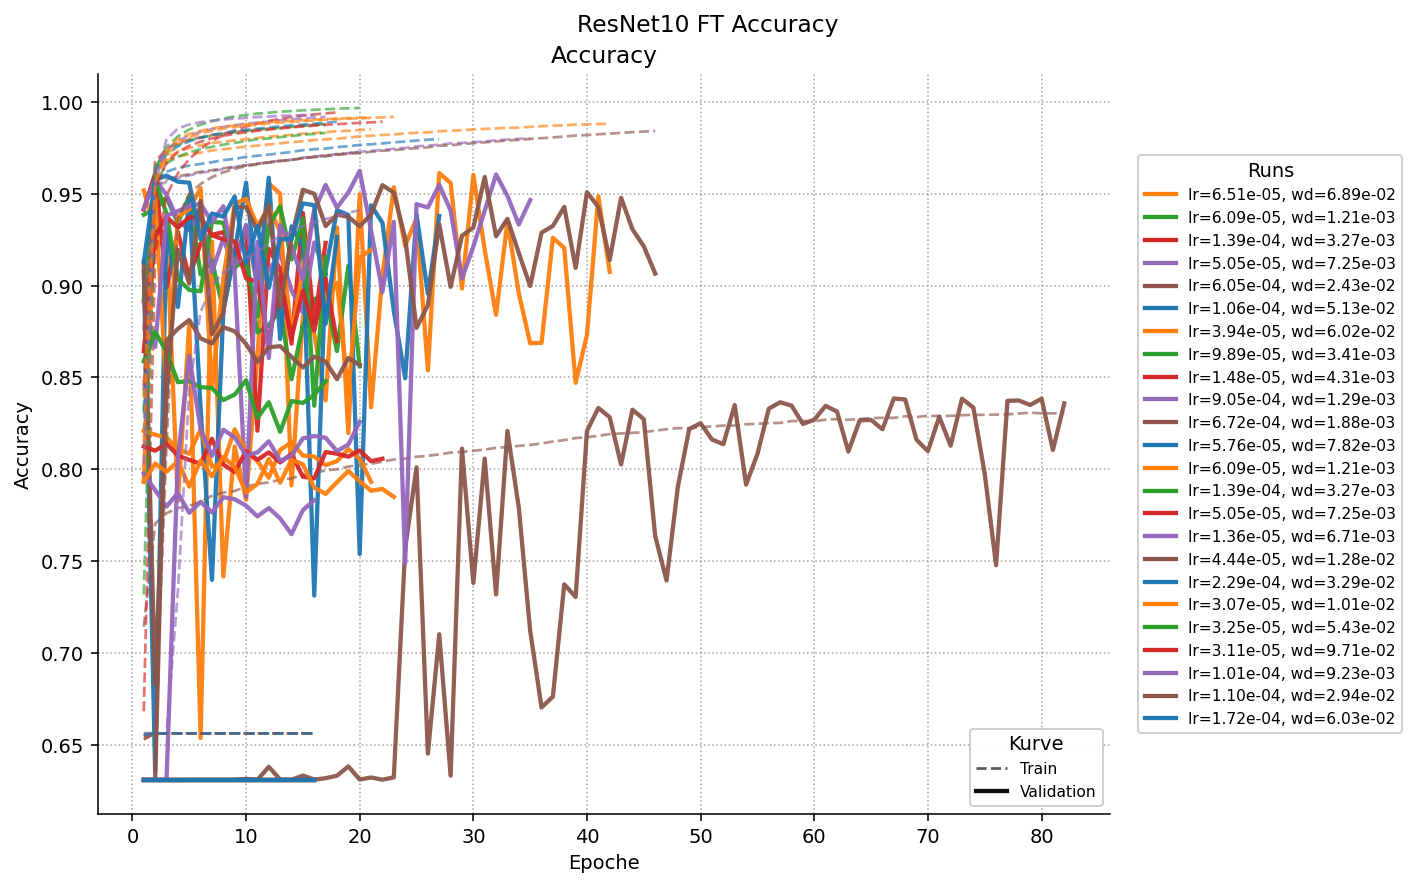

In [5]:
RUN_COLORS = [
    "#1f77b4",  # Blau
    "#ff7f0e",  # Orange
    "#2ca02c",  # Gruen
    "#d62728",  # Rot
    "#9467bd",  # Violett
    "#8c564b",  # Braun
]


def color_for_run(run_number: int):
    return RUN_COLORS[(run_number - 1) % len(RUN_COLORS)]


def plot_accuracy(ax):
    plotted_any = False
    for _, run in runs[runs["n_points"] > 0].sort_values("run_number").iterrows():
        color = color_for_run(int(run.run_number))
        for split, linestyle, alpha, linewidth in (("train", "--", 0.65, 1.4), ("val", "-", 0.95, 2.2)):
            data = scalars[
                (scalars["run_path"] == run.run_path)
                & (scalars["metric"] == "Accuracy")
                & (scalars["split"] == split)
            ].sort_values("epoch")
            if data.empty:
                continue
            ax.plot(data["epoch"], data["value"], color=color, linestyle=linestyle, alpha=alpha, linewidth=linewidth)
            plotted_any = True

    ax.set_title("Accuracy")
    ax.set_xlabel("Epoche")
    ax.set_ylabel("Accuracy")
    ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
    ax.grid(True, linestyle=":", alpha=0.7, color="gray")
    if not plotted_any:
        ax.text(0.5, 0.5, "Keine Accuracy-Daten", ha="center", va="center", transform=ax.transAxes)


fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
plot_accuracy(ax)

run_handles = [
    Line2D([0], [0], color=color_for_run(int(run.run_number)), linewidth=2.2, label=run.legend_label)
    for _, run in runs[runs["n_points"] > 0].sort_values("run_number").iterrows()
]
style_handles = [
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.4, alpha=0.65, label="Train"),
    Line2D([0], [0], color="black", linestyle="-", linewidth=2.2, alpha=0.95, label="Validation"),
]

first_legend = ax.legend(handles=style_handles, loc="lower right", title="Kurve", fontsize=8)
ax.add_artist(first_legend)
ax.legend(handles=run_handles, loc="center left", bbox_to_anchor=(1.02, 0.5), title="Runs", fontsize=8)

fig.suptitle("ResNet10 FT Accuracy", y=1.03)

png_path = OUT_DIR / "resnet10ft_accuracy_train_val_runs.png"
pdf_path = OUT_DIR / "resnet10ft_accuracy_train_val_runs.pdf"
fig.savefig(png_path)
fig.savefig(pdf_path)

png_path, pdf_path